In [4]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import *


In [5]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [8]:
# Setup paths
curr_dir = os.getcwd()
# Assuming the notebook is in snnTorch/generalization_madrid
SPIKES_ROOT = os.path.join(curr_dir, "data")
DATA_FILE = os.path.join(SPIKES_ROOT, "power_analysis_results_center_peak.pkl")

print(f"Looking for data at: {DATA_FILE}")

if not os.path.exists(DATA_FILE):
    print("Data file not found. Please run power_analysis.py first.")
else:
    with open(DATA_FILE, 'rb') as f:
        all_power_data = pickle.load(f)
    print(f"Loaded data for keys: {list(all_power_data.keys())}")

Looking for data at: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\data\power_analysis_results_center_peak.pkl
Loaded data for keys: [('adapt20_3b', 20), ('dsb4updn_median_200_11b', 20), ('dsb4updn_median_200_11f', 20), ('dsb4updn_median_200_12b', 20), ('dsb4updn_median_200_13f', 20), ('dsb4updn_median_200_14b', 20), ('dsb4updn_median_200_15f', 20), ('dsb4updn_median_200_16b', 20), ('dsb4updn_median_200_9f', 20), ('updnb4ds_100_13b', 20), ('updnb4ds_100_13f', 20), ('updnb4ds_100_7', 20)]


In [9]:
def prepare_dataframe(all_power_data):
    records = []
    
    for (network, adapt), events in all_power_data.items():
        for event_type in ['TP', 'FP', 'FN']:
            snippets = events[event_type]
            for s in snippets:
                if len(s) == 0: continue
                
                # Calculate metrics
                peak_power = np.max(s)
                mean_power = np.mean(s)
                
                records.append({
                    'Network': network,
                    'Adapt': adapt,
                    'Type': event_type,
                    'Peak Power': peak_power,
                    'Mean Power': mean_power,
                    'Trace': s
                })
    
    return pd.DataFrame(records)

if os.path.exists(DATA_FILE):
    df = prepare_dataframe(all_power_data)
    print(f"Created DataFrame with {len(df)} records")
    display(df.head())

Created DataFrame with 16329 records


,Network,Adapt,Type,Peak Power,Mean Power,Trace
0,adapt20_3b,20,TP,25.816340,1.123975,"[-0.10516725827752574, -0.10525073763617743, -..."
1,adapt20_3b,20,TP,23.850346,1.283484,"[-0.029438781181509593, -0.029939591244471847,..."
2,adapt20_3b,20,TP,18.660643,0.735210,"[-0.1034822447460555, -0.1039927556559314, -0...."
3,adapt20_3b,20,TP,48.315762,6.335400,"[-0.08153591503820296, -0.0835399185579033, -0..."
4,adapt20_3b,20,TP,21.587914,0.730963,"[-0.08642715304700191, -0.0892182203176365, -0..."


C:\Users\NCN\AppData\Local\Temp\ipykernel_24076\3091155501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y='Peak Power', order=order, inner="quartile", ax=ax, palette="muted")


Statistical Significance (Mann-Whitney U Test) - Aggregated:
TP vs FP: p-value = 0.0000e+00 (***)
TP vs FN: p-value = 3.9027e-206 (***)
FP vs FN: p-value = 5.5817e-21 (***)


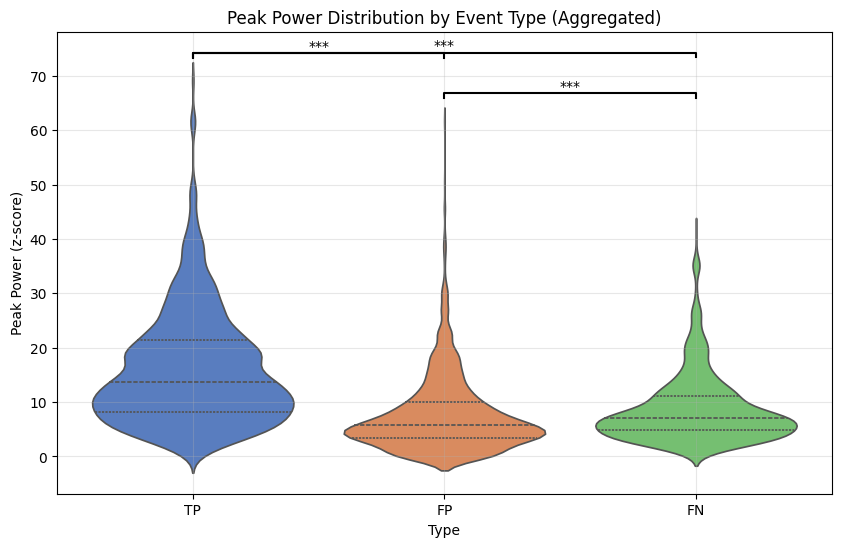

In [14]:
from scipy.stats import mannwhitneyu

# 1. Peak Power Analysis
if os.path.exists(DATA_FILE) and not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define order for consistency
    order = ['TP', 'FP', 'FN']
    
    # Aggregate plot - no hue, specific order
    sns.violinplot(data=df, x='Type', y='Peak Power', order=order, inner="quartile", ax=ax, palette="muted")
    # sns.stripplot(data=df, x='Type', y='Peak Power', order=order, ax=ax, color="black", alpha=0.3, jitter=True)

    ax.set_title('Peak Power Distribution by Event Type (Aggregated)')
    ax.set_ylabel('Peak Power (z-score)')
    ax.grid(True, alpha=0.3)
    
    # Statistical testing on aggregated data
    print("Statistical Significance (Mann-Whitney U Test) - Aggregated:")
    
    # Get distributions
    tp_vals = df[df['Type'] == 'TP']['Peak Power']
    fp_vals = df[df['Type'] == 'FP']['Peak Power']
    fn_vals = df[df['Type'] == 'FN']['Peak Power']
    
    # Prepare heights and centers for annotation
    max_tp = tp_vals.max() if not tp_vals.empty else 0
    max_fp = fp_vals.max() if not fp_vals.empty else 0
    max_fn = fn_vals.max() if not fn_vals.empty else 0
    
    heights = [max_tp, max_fp, max_fn]
    centers = [0, 1, 2]

    # Compare TP (0) vs FP (1)
    if len(tp_vals) > 0 and len(fp_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fp_vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"TP vs FP: p-value = {p:.4e} ({sig})")
        barplot_annotate_brackets(0, 1, p, centers, heights, ax, barh=0.01, maxasterix=3)
        
    # Compare TP (0) vs FN (2)
    if len(tp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fn_vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"TP vs FN: p-value = {p:.4e} ({sig})")
        barplot_annotate_brackets(0, 2, p, centers, heights, ax, barh=0.01, maxasterix=3)

    # Compare FP (1) vs FN (2)
    if len(fp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(fp_vals, fn_vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"FP vs FN: p-value = {p:.4e} ({sig})")
        barplot_annotate_brackets(1, 2, p, centers, heights, ax, barh=0.01, maxasterix=3)

    plt.show()

C:\Users\NCN\AppData\Local\Temp\ipykernel_24076\515733169.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y='Mean Power', order=order, inner="quartile", ax=ax, palette="muted")


Statistical Significance (Mann-Whitney U Test) - Aggregated:
TP vs FP: p-value = 0.0000e+00 (***)
TP vs FN: p-value = 6.4769e-127 (***)
FP vs FN: p-value = 1.4741e-07 (***)


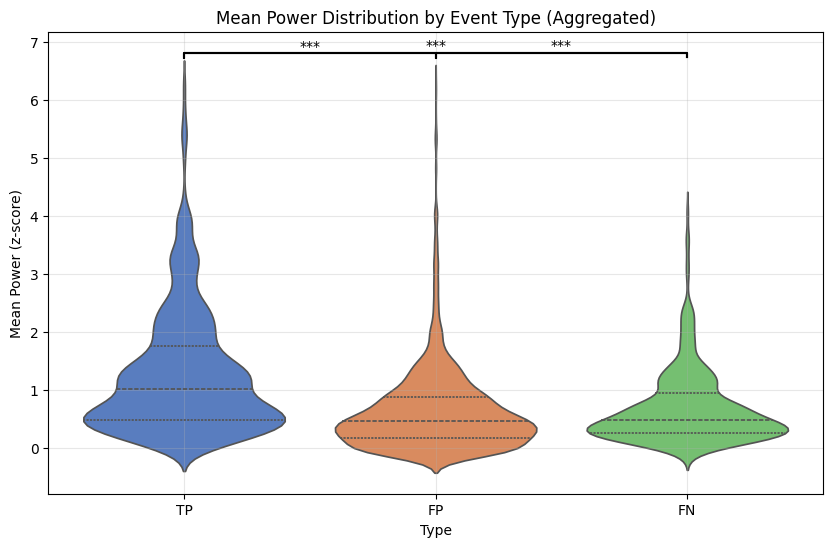

In [12]:
# 2. Mean Power Analysis
if os.path.exists(DATA_FILE) and not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    order = ['TP', 'FP', 'FN']
    
    sns.violinplot(data=df, x='Type', y='Mean Power', order=order, inner="quartile", ax=ax, palette="muted")
    # sns.stripplot(data=df, x='Type', y='Mean Power', order=order, ax=ax, color="black", alpha=0.3, jitter=True)

    ax.set_title('Mean Power Distribution by Event Type (Aggregated)')
    ax.set_ylabel('Mean Power (z-score)')
    ax.grid(True, alpha=0.3)

    # Statistical testing
    print("Statistical Significance (Mann-Whitney U Test) - Aggregated:")
    
    tp_vals = df[df['Type'] == 'TP']['Mean Power']
    fp_vals = df[df['Type'] == 'FP']['Mean Power']
    fn_vals = df[df['Type'] == 'FN']['Mean Power']
    
    # Prepare heights and centers for annotation
    max_tp = tp_vals.max() if not tp_vals.empty else 0
    max_fp = fp_vals.max() if not fp_vals.empty else 0
    max_fn = fn_vals.max() if not fn_vals.empty else 0
    
    heights = [max_tp, max_fp, max_fn]
    centers = [0, 1, 2]

    # Compare TP vs FP
    if len(tp_vals) > 0 and len(fp_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fp_vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"TP vs FP: p-value = {p:.4e} ({sig})")
        barplot_annotate_brackets(0, 1, p, centers, heights, ax, barh=0.01, maxasterix=3)
            
    # Compare TP vs FN
    if len(tp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fn_vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"TP vs FN: p-value = {p:.4e} ({sig})")
        barplot_annotate_brackets(0, 2, p, centers, heights, ax, barh=0.01, maxasterix=3)

    # Compare FP vs FN
    if len(fp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(fp_vals, fn_vals)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"FP vs FN: p-value = {p:.4e} ({sig})")
        barplot_annotate_brackets(1, 2, p, centers, heights, ax, barh=0.01, maxasterix=3)

    plt.show()

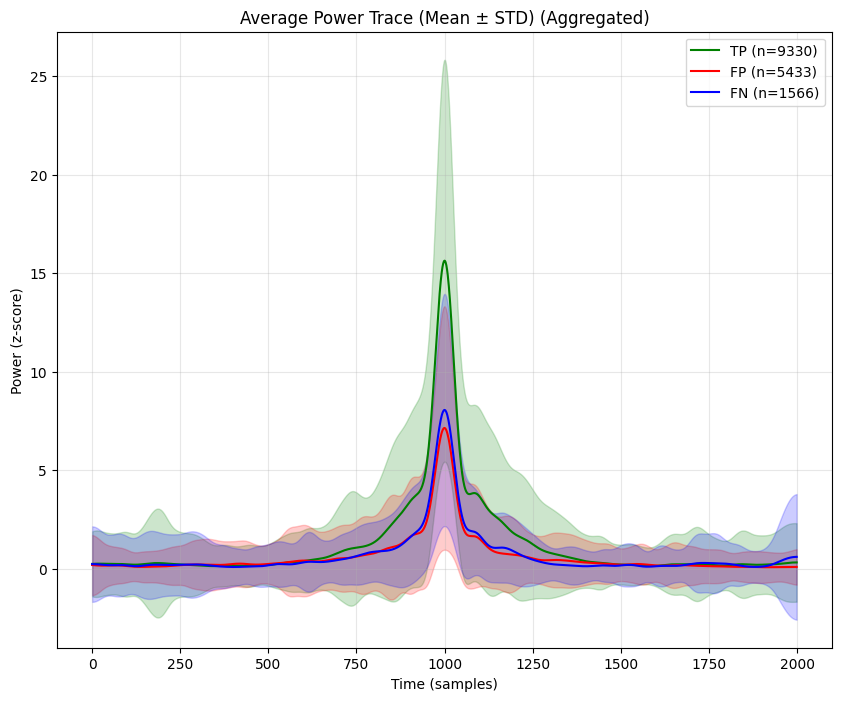

In [ ]:
# 3. Power Trace Analysis (Whole Window)
if os.path.exists(DATA_FILE) and not df.empty:
    # Function to plot traces with CI
    def plot_traces(data_df, title_suffix=""):
        plt.figure(figsize=(10, 8))
        
        event_types = ['TP', 'FP', 'FN']
        colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
        
        # Check trace length from first record
        trace_len = len(data_df.iloc[0]['Trace'])
        x_axis = np.arange(trace_len)
        
        for et in event_types:
            subset = data_df[data_df['Type'] == et]
            if subset.empty: continue
            
            # Stack traces: (N_samples, Time_points)
            traces = np.stack(subset['Trace'].values)
            
            # mean_trace = np.mean(traces, axis=0)
            mean_trace = np.median(traces, axis=0)
            std_trace = np.std(traces, axis=0)
            
            # 95% CI approx
            ci = 1.96 * std_trace / np.sqrt(len(traces))
            
            # Using STD for visualization as requested
            upper = mean_trace + std_trace
            lower = mean_trace - std_trace
            
            plt.plot(x_axis, mean_trace, label=f'{et} (n={len(traces)})', color=colors[et])
            plt.fill_between(x_axis, lower, upper, color=colors[et], alpha=0.2)
            
        plt.title(f'Average Power Trace (Mean ± STD) {title_suffix}')
        plt.xlabel('Time (samples)')
        plt.ylabel('Power (z-score)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # Plot aggregated across all networks/adapts
    plot_traces(df, title_suffix="(Aggregated)")